In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
 
rng = np.random.default_rng(42)

/var/folders/l2/2wb9q9r153xcwtl9181zn89w0000gn/T/ipykernel_43002/3737058588.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(g, stats.uniform.cdf(g), "k--", lw=1, color = 'pink', label="Theoretical CDF")


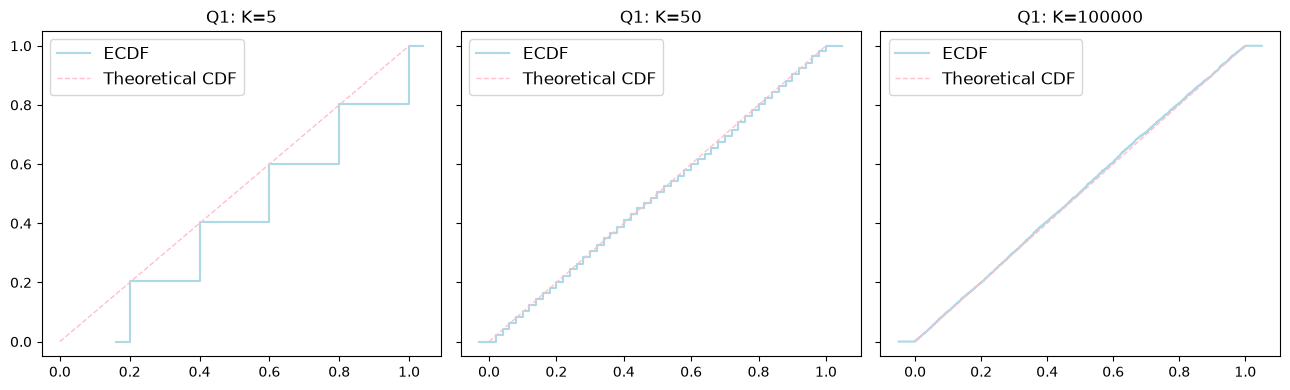

In [ ]:
#q1
fig, axs = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
Ks = [5, 50, 100_000]
summary = []

for ax, K in zip(axs, Ks):
    x = np.random.default_rng().integers(1, K + 1, 5_000) / K
    stats.ecdf(x).cdf.plot(ax, label="ECDF", color = 'lightblue')
    g = np.linspace(0, 1, 100)
    ax.plot(g, stats.uniform.cdf(g), "k--", lw=1, color = 'pink', label="Theoretical CDF")
    ax.set_title(f"Q1: K={K}", fontsize=12)
    ax.legend(fontsize=12)
    ks_stat = stats.kstest(x, "uniform").statistic
    summary.append(("Q1", f"K={K}", "Uniform(0,1)", ks_stat))

plt.tight_layout()
plt.show()

When K grows, the size of the grids become smaller and smaller so it looks more continuous as K increases (Uniform(0,1)).

/var/folders/l2/2wb9q9r153xcwtl9181zn89w0000gn/T/ipykernel_43002/1716025503.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(g, stats.norm.cdf(g), "k--", lw=1, color = 'pink', label="Theoretical CDF")


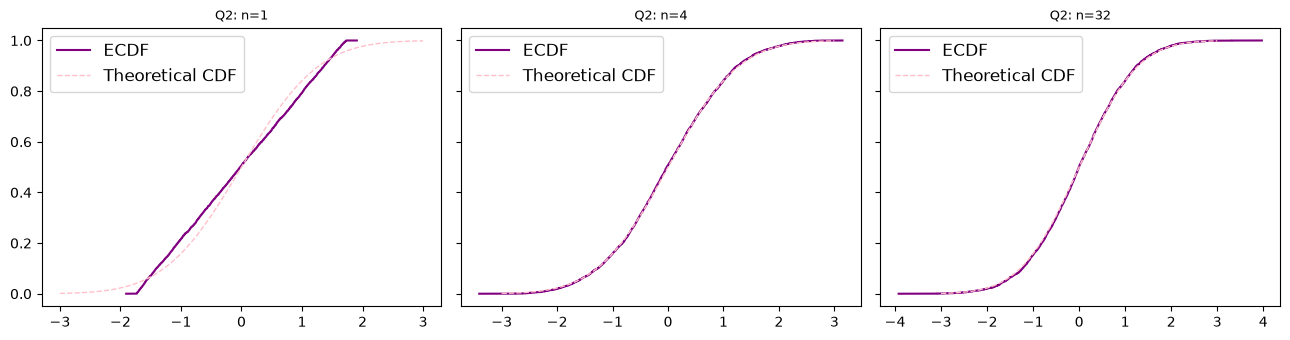

In [8]:
#q2
fig, axs = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
ns = [1, 4, 32]

for ax, n in zip(axs, ns):
    data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(5_000, n))
    z = np.sqrt(n) * data.mean(axis=1)
    stats.ecdf(z).cdf.plot(ax, color = 'purple', label="ECDF")
    g = np.linspace(-3, 3, 100)
    ax.plot(g, stats.norm.cdf(g), "k--", lw=1, color = 'pink', label="Theoretical CDF")
    ax.set_title(f"Q2: n={n}", fontsize=9)
    ax.legend(fontsize=12)
    
    ks_stat = stats.kstest(z, "norm").statistic
    summary.append(("Q2", f"n={n}", "Normal(0,1)", ks_stat))

plt.tight_layout()
plt.show()


Before averaging, its shaped like a uniform distribution and then becomes more bell shaped as n increases and becomes close to standard normal.(Normal(0,1))


/var/folders/l2/2wb9q9r153xcwtl9181zn89w0000gn/T/ipykernel_43002/400979210.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(g, stats.norm.cdf(g), "k--", lw=1, color = 'green',label="Theoretical CDF")


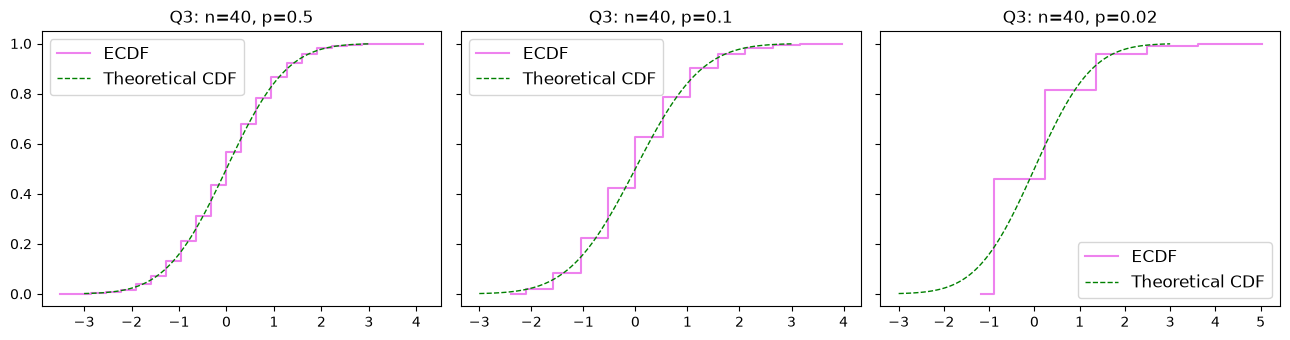

In [ ]:
#q3
fig, axs = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
ps = [0.5, 0.1, 0.02]
n = 40

for ax, p in zip(axs, ps):
    heads = rng.binomial(n, p, 5_000)
    z = (heads - n*p) / np.sqrt(n*p * (1- p))
    stats.ecdf(z).cdf.plot(ax, label="ECDF", color = 'violet')
    g = np.linspace(-3, 3, 100)
    ax.plot(g, stats.norm.cdf(g), "k--", lw=1, color = 'green',label="Theoretical CDF")
    ax.set_title(f"Q3: n=40, p={p}", fontsize=12)
    ax.legend(fontsize=12)
    
    ks_stat = stats.kstest(z, "norm").statistic
    summary.append(("Q3", f"p={p}", "Normal(0,1)", ks_stat))

plt.tight_layout()
plt.show()


It starts off with the fit being good at p=0.5 but as it decreases, it becomes more and more skewed. (Normal(0,1))

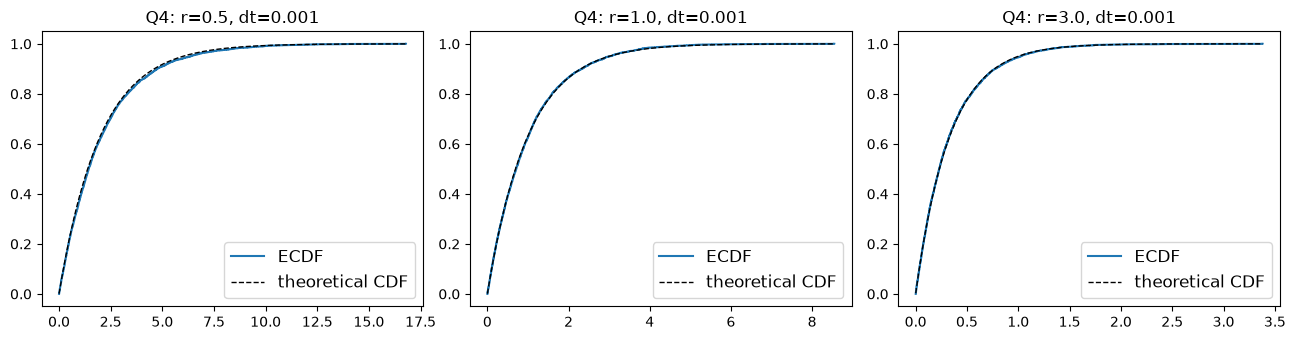

In [ ]:
#q4

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
rs = [0.5, 1.0, 3.0]
dt = 1e-3

for ax, r in zip(axs, rs):
    periods = rng.geometric(r * dt, 5_000)
    t = periods * dt
    
    xs = np.sort(t)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.step(xs, ys, where="post", label="ECDF")
    g = np.linspace(xs.min(), xs.max(), 500)
    cdf_fn = lambda val: stats.expon.cdf(val, scale=1 / r)
    ax.plot(g, cdf_fn(g), "k--", lw=1, label="theoretical CDF")
    ax.set_title(f"Q4: r={r}, dt={dt}", fontsize=12)
    ax.legend(fontsize=12)
    ks_stat = stats.kstest(t, cdf_fn).statistic
    summary.append(("Q4", f"r={r}", "Exponential(lam=r)", ks_stat))

plt.tight_layout()
plt.show()


as dt -> 0, the time between events start to turn more continuous into an exponential distribution (Exponential(rate = r)). Adjusting r just changes the size of the distribution and rescales it, but the shape stays the same.